# 🎨 PixArt-Sigma LoRA 10k Training & Baseline Evaluation Report

This interactive notebook provides full visualization, statistical analysis, and visual progression grids for fine-tuning **PixArt-Sigma DiT** with **LoRA Rank 16** over **10,000 training steps** across four dataset configurations, evaluated against the **Un-adapted Base Model (Step 0 Baseline)**.

### 📌 Experiment Summary & Matrix
| Dataset ID | Description | Sample Count ($N$) | Category Focus | LoRA Rank ($r$) | Max Steps | Guidance Scale |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **`baseline`** | Un-adapted Base Transformer | 0 (Base Model) | N/A | None | 0 | 1.5 |
| **`n50`** | Small Subset | 50 samples | Mixed | 16 | 10,000 | 1.5 |
| **`n100`** | Medium Subset | 100 samples | Mixed | 16 | 10,000 | 1.5 |
| **`plant209`** | Plant Domain Subset | 209 samples | Plant Only (`plant/*`) | 16 | 10,000 | 1.5 |
| **`n260`** | Full Dataset | 260 samples | Full Canonical Dataset | 16 | 10,000 | 1.5 |

In [1]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from PIL import Image

# Robust repository root resolution
def get_repository_root() -> Path:
    curr = Path.cwd().resolve()
    for parent in [curr] + list(curr.parents):
        if (parent / "README.md").is_file() or (parent / ".git").is_dir():
            return parent
    return curr

root_dir = get_repository_root()
output_root = root_dir / "outputs" / "experiment_10k"

print(f"Repository Root: {root_dir}")
print(f"Experiment Root: {output_root}")
print(f"PyTorch Version: {torch.__version__} (CUDA Available: {torch.cuda.is_available()})")

Repository Root: C:\dev\efficient-pixart-sigma-lora
Experiment Root: C:\dev\efficient-pixart-sigma-lora\outputs\experiment_10k
PyTorch Version: 2.5.1+cu121 (CUDA Available: True)


## 1. 📊 Experiment Metrics Table & Summary Data

In [2]:
metrics_csv = output_root / "metrics_10k.csv"
if metrics_csv.is_file():
    df = pd.read_csv(metrics_csv)
    print(f"Total Checkpoint Evaluation Rows: {len(df)}")
    display(df.sort_values(["dataset", "step"]))
else:
    print(f"Metrics CSV not found at {metrics_csv}. Background training task is actively generating outputs.")

Total Checkpoint Evaluation Rows: 45


,dataset,num_images,rank,step,guidance_scale,clip_score,latency_sec,image_path
0,baseline,0,0,0,1.5,0.383973,22.0600,outputs\experiment_10k\eval_generations\baseli...
12,n100,100,16,1000,1.5,0.392452,17.1765,outputs\experiment_10k\eval_generations\n100\s...
13,n100,100,16,2000,1.5,0.385233,17.5934,outputs\experiment_10k\eval_generations\n100\s...
14,n100,100,16,3000,1.5,0.380116,17.4879,outputs\experiment_10k\eval_generations\n100\s...
15,n100,100,16,4000,1.5,0.379197,17.3727,outputs\experiment_10k\eval_generations\n100\s...
16,n100,100,16,5000,1.5,0.376884,17.0113,outputs\experiment_10k\eval_generations\n100\s...
17,n100,100,16,6000,1.5,0.376843,17.7862,outputs\experiment_10k\eval_generations\n100\s...
18,n100,100,16,7000,1.5,0.371397,18.4390,outputs\experiment_10k\eval_generations\n100\s...
19,n100,100,16,8000,1.5,0.350971,17.7064,outputs\experiment_10k\eval_generations\n100\s...
20,n100,100,16,9000,1.5,0.372287,17.7531,outputs\experiment_10k\eval_generations\n100\s...


## 2. 📈 CLIPScore Trajectory Curve (Step 0 Baseline vs. 1,000–10,000 Steps)

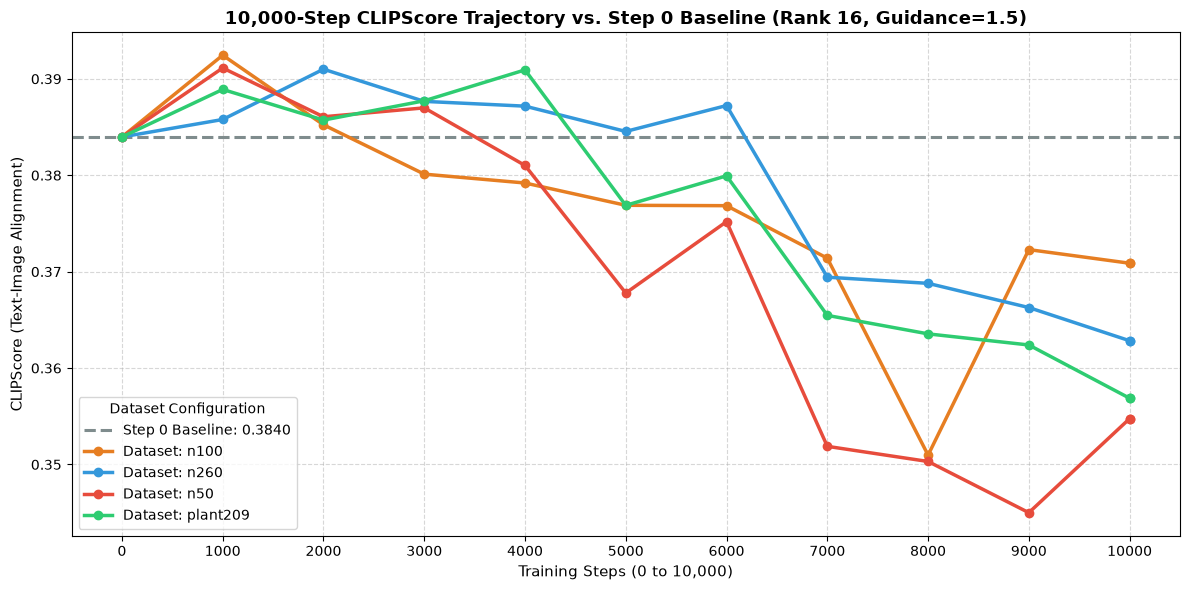

In [3]:
if metrics_csv.is_file():
    plt.figure(figsize=(12, 6))
    colors = {"baseline": "#7f8c8d", "n50": "#e74c3c", "n100": "#e67e22", "plant209": "#2ecc71", "n260": "#3498db"}
    
    base_df = df[df["dataset"] == "baseline"]
    base_score = base_df["clip_score"].values[0] if not base_df.empty else None
    
    if base_score is not None:
        plt.axhline(y=base_score, color=colors["baseline"], linestyle="--", linewidth=2.2, label=f"Step 0 Baseline: {base_score:.4f}")
    
    for dataset_name, group in df.groupby("dataset"):
        if dataset_name == "baseline":
            continue
        group_sorted = group.sort_values("step")
        steps = [0] + group_sorted["step"].tolist() if base_score is not None else group_sorted["step"].tolist()
        scores = [base_score] + group_sorted["clip_score"].tolist() if base_score is not None else group_sorted["clip_score"].tolist()
        
        plt.plot(
            steps,
            scores,
            marker="o",
            linewidth=2.5,
            color=colors.get(dataset_name, "purple"),
            label=f"Dataset: {dataset_name}"
        )
    
    plt.title("10,000-Step CLIPScore Trajectory vs. Step 0 Baseline (Rank 16, Guidance=1.5)", fontsize=13, fontweight="bold")
    plt.xlabel("Training Steps (0 to 10,000)", fontsize=11)
    plt.ylabel("CLIPScore (Text-Image Alignment)", fontsize=11)
    plt.xticks(range(0, 11000, 1000))
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Dataset Configuration", fontsize=10)
    plt.tight_layout()
    plt.show()

## 3. 🖼️ Visual Progression: Step 0 (Baseline) to Step 10,000 Checkpoints

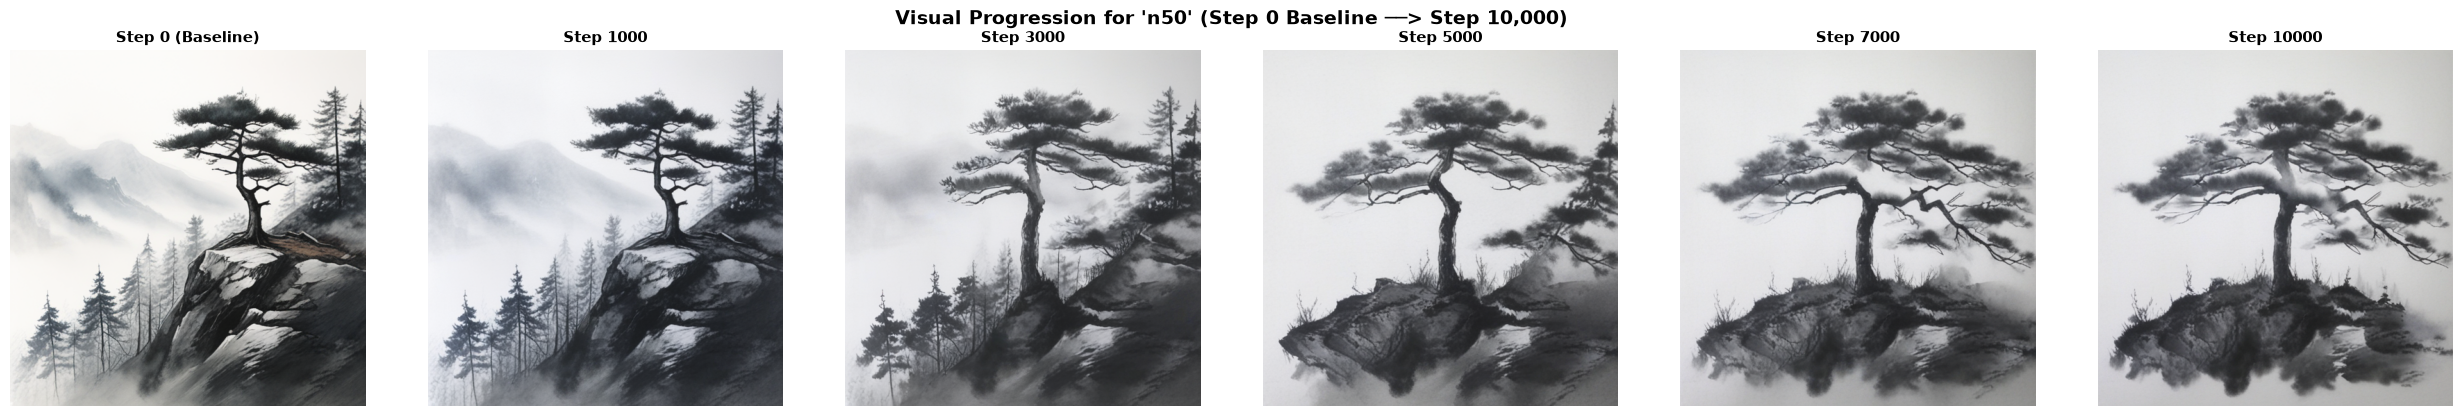

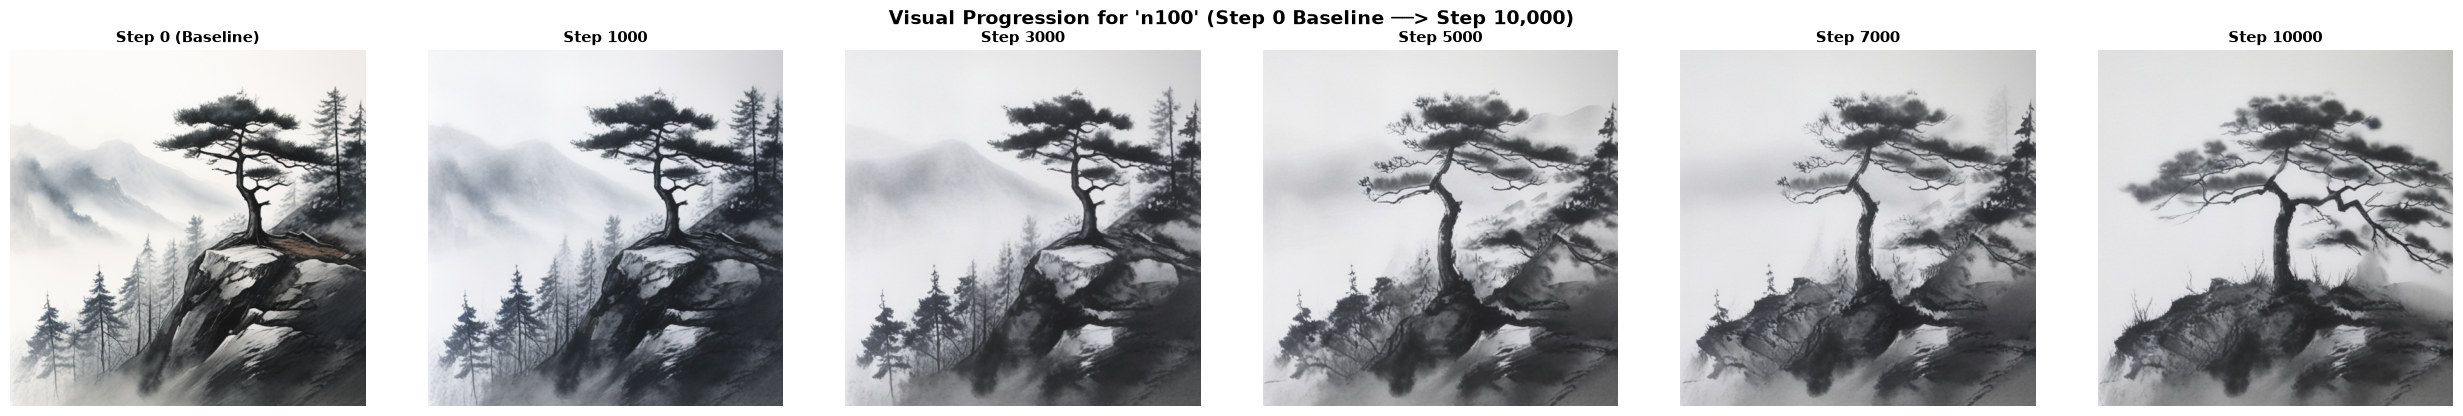

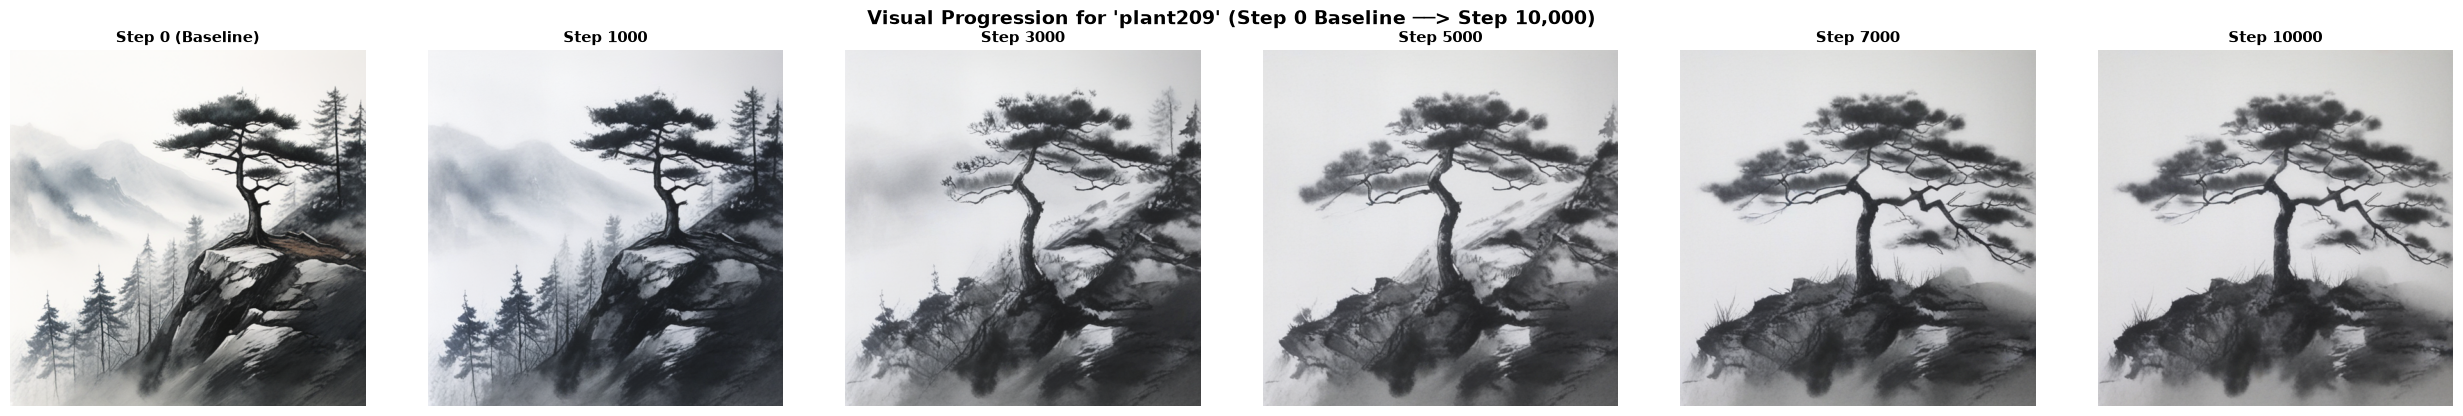

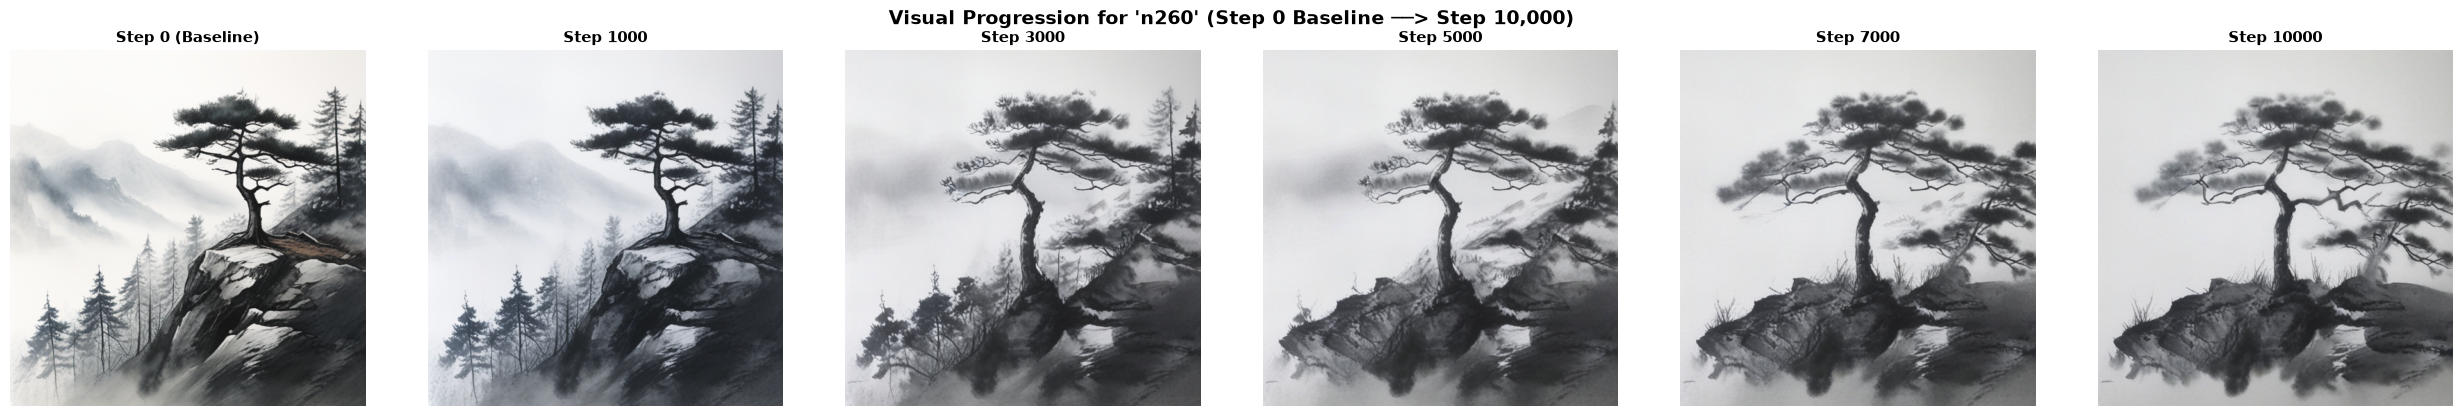

In [4]:
def render_visual_progression(dataset_name: str, steps=[0, 1000, 3000, 5000, 7000, 10000]):
    fig, axes = plt.subplots(1, len(steps), figsize=(4.2 * len(steps), 4.2))
    fig.suptitle(f"Visual Progression for '{dataset_name}' (Step 0 Baseline ──> Step 10,000)", fontsize=14, fontweight="bold")
    
    for idx, step in enumerate(steps):
        if step == 0:
            img_path = output_root / "eval_generations" / "baseline" / "step_0.png"
        else:
            img_path = output_root / "eval_generations" / dataset_name / f"step_{step}.png"
            
        if img_path.is_file():
            img = Image.open(img_path)
            axes[idx].imshow(img)
            title_str = "Step 0 (Baseline)" if step == 0 else f"Step {step}"
            axes[idx].set_title(title_str, fontsize=11, fontweight="bold")
            axes[idx].axis("off")
        else:
            axes[idx].text(0.5, 0.5, f"Step {step}\n(Pending)", ha="center", va="center", fontsize=11)
            axes[idx].axis("off")
            
    plt.tight_layout()
    plt.show()

for ds in ["n50", "n100", "plant209", "n260"]:
    render_visual_progression(ds)